# CORDIS → UN SDG Target Mapping

Evaluator-facing frozen-output reproducibility notebook. It performs **no inference** and changes no mapping. The release contains 150 projects, 231 supported relationships and four preserved system-invalid cases. Results below are recomputed from included files; integrity checks are not evidence of semantic accuracy.

## A. Problem definition

Map each project to zero or more exact UN SDG Targets. Broad topic similarity and isolated keywords are insufficient: target actions and qualifiers require project evidence. Retrieval proposes candidates; semantic verification assesses them. A project may remain unmapped.

In [1]:
from pathlib import Path
import json, hashlib, csv
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'data/cordis_sdg_mapping.csv').is_file():
    raise RuntimeError('Run from the release root or its notebooks directory.')
def load_json(name):
    return json.loads((ROOT / 'artifacts' / name).read_text(encoding='utf-8'))
mapping = pd.read_csv(ROOT / 'data/cordis_sdg_mapping.csv', dtype={'project_id':str, 'target_code':str}, keep_default_na=False)
projects = pd.read_csv(ROOT / 'data/project_mapping_summary.csv', dtype={'project_id':str}, keep_default_na=False)
corpus = pd.read_csv(ROOT / 'data/final_projects_150_privacy_clean.csv', dtype={'project_id':str}, keep_default_na=False)
candidates = pd.read_csv(ROOT / 'artifacts/final_candidate_pairs_1500.csv', dtype={'project_id':str,'target_code':str})
uncertain = pd.read_csv(ROOT / 'data/uncertain_system_cases.csv', dtype={'project_id':str})
responses = [json.loads(line) for line in (ROOT / 'artifacts/final_responses.jsonl').read_text(encoding='utf-8').splitlines()]
quality = load_json('quality_report.json')
plt.rcParams.update({'font.size':11, 'axes.spines.top':False, 'axes.spines.right':False, 'figure.dpi':120})


## B. Data source

Source: CORDIS project data. The frozen processed source is recorded in the manifest below, with its SHA-256. The full source population is not published here. **The exact original upstream retrieval/download date is unavailable**; later timestamps are not substitutes. This notebook consumes only the frozen privacy-clean demonstration corpus.

In [2]:
source_manifest = load_json('final_corpus_manifest.json')
pd.Series({k:source_manifest[k] for k in ['source_file','source_sha256','eligible_population_after_exclusions','selected_projects']}, name='Recorded source provenance')

source_file                                             data\processed\projects_clean.csv
source_sha256                           003dd63261ba9d31433c7c6f6753d55135700f4c88e53b...
eligible_population_after_exclusions                                                23329
selected_projects                                                                     150
Name: Recorded source provenance, dtype: object

## C. Final corpus construction

The retained manifest describes deterministic balanced-proportional stratification, minimum 250 objective characters, development/validation exclusions and 24 reserve IDs excluded using metadata. It records no SDG-label or prior-prediction use. Those selection-stage claims are retained provenance; final selection code was not recovered, so no fresh population selection is reproduced here. The privacy amendment corrected an omitted eligibility screen using six replacements with the same deterministic ordering and stratum allocation. No reserve text is included or inspected. This is a controlled demonstration, not a probability sample.

In [3]:
display(pd.Series(source_manifest['stratum_distribution'], name='Projects').to_frame())
amendment = load_json('final_corpus_privacy_amendment.json')
display(pd.DataFrame({'Removed ID (set order, not paired replacements)':amendment['removed_project_ids'], 'Replacement ID (set order)':amendment['replacement_project_ids']}))
display(corpus.groupby('framework').size().rename('Final projects').to_frame())

,Projects
HORIZON_EUROPE|2021_2023,40
HORIZON_EUROPE|2024_PLUS,68
OTHER|2021_2023,15
OTHER|2024_PLUS,27


,"Removed ID (set order, not paired replacements)",Replacement ID (set order)
0,101040948,101039986
1,101066452,101114249
2,101153525,101131175
3,101201413,101131435
4,101207854,101135576
5,101295861,101217199


,Final projects
framework,
HORIZON_EUROPE,108
OTHER,42


## D. SDG taxonomy

The retained EU Vocabularies concept export contains 17 Goals, 169 Targets and additional Indicator/Series concepts. Production evaluated **Targets only**. Blank `narrower_concept` does not mean each narrower concept was evaluated and rejected. The exact wording and URI matter, including qualifiers.

In [4]:
taxonomy = pd.read_csv(ROOT / 'data/taxonomy_concepts.csv', keep_default_na=False)
targets = taxonomy[taxonomy['types'].str.split('|').apply(lambda ts: 'http://metadata.un.org/sdg/ontology#Target' in ts)]
goals = taxonomy[taxonomy['types'].str.split('|').apply(lambda ts: 'http://metadata.un.org/sdg/ontology#Goal' in ts)]
if len(targets) != 169 or len(goals) != 17:
    raise ValueError('Unexpected taxonomy cardinality')
display(pd.Series({'All concepts':len(taxonomy),'Goals':len(goals),'Targets used in production':len(targets)}).to_frame('Count'))
display(targets[['code','label','concept_uri']].head())

,Count
All concepts,812
Goals,17
Targets used in production,169


,code,label,concept_uri
1,1.1,"By 2030, eradicate extreme poverty for all peo...",http://data.europa.eu/sdg/1.1
2,1.2,"By 2030, reduce at least by half the proportio...",http://data.europa.eu/sdg/1.2
3,1.3,Implement nationally appropriate social protec...,http://data.europa.eu/sdg/1.3
4,1.4,"By 2030, ensure that all men and women, in par...",http://data.europa.eu/sdg/1.4
5,1.5,"By 2030, build the resilience of the poor and ...",http://data.europa.eu/sdg/1.5


## E. Retrieval

Recorded model: `sentence-transformers/all-MiniLM-L6-v2`; objective chunk width **220**, overlap **40**; score = **0.7 × max(objective chunk similarity) + 0.3 × metadata similarity**. Available title, keywords, EuroSciVoc and Horizon/topic metadata contribute. Top K=10 over 169 Targets yields 1,500 candidates. Scores are similarities, not probabilities. Targets outside the top ten cannot be recovered. The final manifest has no immutable retriever revision; final retrieval orchestration was not recovered. We inspect frozen rankings rather than rerun embeddings.

In [5]:
display(pd.Series(load_json('retrieval_manifest.json')).to_frame('Recorded retrieval setting'))
rank_counts = candidates.groupby('project_id').size()
if len(rank_counts)!=150 or not rank_counts.eq(10).all():
    raise ValueError('Unexpected candidate population')
display(candidates[['project_id','target_code','retrieval_rank','retrieval_score']].head())

,Recorded retrieval setting
candidate_pairs,1500
candidate_pairs_sha256,6eab96127aacf69215b3acb33e205a15e3bc4883dc6ec2...
chunk_overlap,40
chunk_width,220
evidence_sha256,cb993ee54cb71ebcabf2e28fccd8bde3b1adf126b6a1a2...
openai_api_calls,0
payloads_sha256,b13b4bef875202e41cf3efbf9aee79544662156f565056...
privacy_clean_corpus_sha256,7075a9da63228019f0968b5d7060a4c1ac266ebe421150...
projects,150
reserve_semantic_access,False


,project_id,target_code,retrieval_rank,retrieval_score
0,101067998,7.a,1,0.299728
1,101067998,7.3,2,0.275223
2,101067998,7.2,3,0.261996
3,101067998,7.1,4,0.251950
4,101067998,9.5,5,0.249269


## F. Semantic verification

Frozen V8 Stage 1 checks exact-target scope/eligibility and qualifiers. Only valid eligible cases enter Stage 2 for contribution depth (not taxonomy descent). Deterministic composition returns STRONG/WEAK/UNSUPPORTED and DIRECT/INDIRECT. STRONG requires major/core role, governing-action alignment and performance or substantial target-specific capacity. DIRECT requires an immediate target mechanism. Invalid stages remain invalid. Final deployment model: **gpt-6-luna**; historical GPT-5.4 Mini development metrics are not final Luna accuracy.

## G. Production API configuration

The recorded interface is Responses API with structured JSON-schema output. The extracted configuration below was checked across all 1,500 frozen scope requests. The run summary records zero retries, no human labels transmitted and no reserve semantic access. All 234 retained depth provider responses also echo model gpt-6-luna, max_output_tokens=1536, service_tier=default, reasoning effort none, store=false and no tools. These are response echoes, distinct from the unpublished full outbound depth request bodies. No request is sent by this notebook.

In [6]:
display(pd.Series(load_json('production_configuration.json')['scope_request_configuration']).to_frame('Scope request setting'))
freeze = load_json('freeze_manifest.json')
display(pd.Series({k:v for k,v in freeze.items() if k.endswith('_sha256')}).to_frame('Frozen SHA-256'))
display(pd.Series({k:load_json('run_summary.json')[k] for k in ['scope_calls','depth_calls','retries','human_labels_transmitted','reserve_semantic_access','estimated_cost_usd']}).to_frame('Run record'))

,Scope request setting
max_output_tokens,1536
model,gpt-6-luna
reasoning,{'effort': 'none'}
service_tier,default
store,False
tools,[]


,Frozen SHA-256
candidate_pairs_sha256,6eab96127aacf69215b3acb33e205a15e3bc4883dc6ec2...
candidate_payloads_sha256,b13b4bef875202e41cf3efbf9aee79544662156f565056...
composer_sha256,7ec0981ea8bddf4fb1c1feb585a8dcf763868e11de7f19...
depth_prompt_sha256,334e6e07c7f6652d6146e8b09d164493ad4cd94f21ba1e...
depth_schema_sha256,bbc71cfe704c06abbb93c645f25cd67ae9fdd7bcdc4a1b...
privacy_clean_corpus_sha256,7075a9da63228019f0968b5d7060a4c1ac266ebe421150...
scope_prompt_sha256,94179b56cdec02d4afdf5c87acf22f207881e649b4f5cf...
scope_requests_sha256,876144b6470ad556a3749c65f9439224bc49808c219c5a...
scope_schema_sha256,ff693135c38e894fc5b13def7545fe6b4cc09c8490fea8...


,Run record
scope_calls,1500
depth_calls,234
retries,0
human_labels_transmitted,False
reserve_semantic_access,False
estimated_cost_usd,0.63096


The recorded $0.63096 is a usage-based estimate, not a verified bill. Provider output is not guaranteed reproducible indefinitely; a model ID is not an immutable backend snapshot. Local deterministic composition can be reproduced from retained parsed inputs without an API.

## H. Frozen-prompt framework caveat

The unchanged Stage-1 prompt says **ONE Horizon Europe project**, but the final corpus contains **108 HORIZON_EUROPE and 42 OTHER** projects. Thus 420 scope evaluations used inaccurate framework wording. Verification is target/evidence based, but this does not prove the model ignored that wording. No prompt was changed and no affected mapping was rerun.

In [7]:
other_ids = set(corpus.loc[corpus['framework'].eq('OTHER'),'project_id'])
other_mappings = mapping[mapping['project_id'].isin(other_ids)]
display(pd.Series({'OTHER projects':len(other_ids), 'OTHER scope evaluations':int(candidates['project_id'].isin(other_ids).sum()), 'OTHER supported mappings':len(other_mappings)}).to_frame('Count'))

,Count
OTHER projects,42
OTHER scope evaluations,420
OTHER supported mappings,28


The optional diagnostic CSV checks only literal framework phrases in explanations. It marks semantic dependence UNDETERMINED; absence of a phrase is not proof of absence of an effect.

## I. Human-reviewed development benchmark

24 projects, 240 pairs; two reviewers with 40 shared decisions. Reference labels: STRONG 30, WEAK 18, UNSUPPORTED 192. Pre-adjudication exact agreement 35/40=87.5%, binary agreement 37/40=92.5%; kappa approximately 0.653 and 0.778 on the common project-target units. The aggregate agreement artifact preserves these counts. **V8 FAILED the complete internal development gate.** Repeated development-set reuse means these are development metrics, not an untouched confirmatory estimate or final Luna accuracy.

In [8]:
dev = load_json('development_metrics.json')
metric_keys = ['exact_pct','binary_accuracy_pct','supported_precision_pct','supported_recall_pct','strong_precision_pct','strong_recall_pct','weak_precision_pct','weak_recall_pct','contribution_accuracy_pct']
display(pd.Series({k:round(dev[k],2) for k in metric_keys}).to_frame('Development percent'))
display(pd.Series({'Contribution matches':dev['contribution_matches'],'Contribution evaluable rows (joint support)':dev['contribution_evaluable_rows']}).to_frame('Count'))
display(load_json('development_gate_result.json'))

,Development percent
exact_pct,86.67
binary_accuracy_pct,93.33
supported_precision_pct,90.00
supported_recall_pct,75.00
strong_precision_pct,85.71
strong_recall_pct,40.00
weak_precision_pct,30.77
weak_recall_pct,44.44
contribution_accuracy_pct,77.78


,Count
Contribution matches,28
Contribution evaluable rows (joint support),36


{'checks': {'binary_matches': True,
  'contract_valid': True,
  'contribution_accuracy': True,
  'contribution_evaluable_rows': True,
  'direct_predictions': True,
  'exact_matches': False,
  'indirect_predictions': True,
  'max_invalid': True,
  'strong_precision': True,
  'strong_recall': False,
  'supported_precision': True,
  'supported_recall': False,
  'weak_precision': False,
  'weak_predictions': True,
  'weak_recall': True},
 'result': 'FAIL',
 'thresholds': {'max_invalid': 2,
  'min_binary_matches': 221,
  'min_contract_valid': 238,
  'min_contribution_accuracy': 0.65,
  'min_contribution_evaluable_rows': 35,
  'min_direct_predictions': 10,
  'min_exact_matches': 216,
  'min_indirect_predictions': 5,
  'min_strong_precision': 0.7,
  'min_strong_recall': 0.75,
  'min_supported_precision': 0.8,
  'min_supported_recall': 0.8,
  'min_weak_precision': 0.5,
  'min_weak_predictions': 5,
  'min_weak_recall': 0.4}}

Contribution accuracy is 28/36 jointly supported pairs, not 28/240 or a final-production measure. Failed gate checks: exact matches (208<216), STRONG recall (40%<75%), supported recall (75%<80%) and WEAK precision (30.77%<50%).

## J. Final production results

The following table is recomputed from the frozen mapping, candidate, summary and response files. The 50 unmapped projects were not forced into a class; it means no supported target within their retrieved candidates, not absence of all possible SDG contribution.

In [9]:
valid = [r for r in responses if r['final_contract_valid']]
n = projects['n_supported_mappings']
results = {'Projects':len(projects),'Candidate pairs':len(candidates),'Contract-valid':len(valid),'Contract-invalid':len(responses)-len(valid),'Supported mappings':len(mapping),'Mapped projects':mapping['project_id'].nunique(),'Unmapped projects':int(n.eq(0).sum()),'HIGH / STRONG':int(mapping['confidence_level'].eq('HIGH').sum()),'MEDIUM / WEAK':int(mapping['confidence_level'].eq('MEDIUM').sum()),'UNSUPPORTED':sum(r['final_result']['judgment']=='UNSUPPORTED' for r in valid),'DIRECT':int(mapping['contribution_type'].eq('DIRECT').sum()),'INDIRECT':int(mapping['contribution_type'].eq('INDIRECT').sum()),'Mean mappings/project':n.mean(),'Mean mappings/mapped project':n[n.gt(0)].mean(),'Maximum mappings/project':int(n.max())}
expected = [150,1500,1496,4,231,100,50,88,143,1265,188,43,1.54,2.31,6]
if any(abs(float(v)-e)>1e-10 for v,e in zip(results.values(),expected)):
    raise ValueError('Result count differs from frozen expectations')
display(pd.Series(results).to_frame('Recomputed value'))

,Recomputed value
Projects,150.00
Candidate pairs,1500.00
Contract-valid,1496.00
Contract-invalid,4.00
Supported mappings,231.00
Mapped projects,100.00
Unmapped projects,50.00
HIGH / STRONG,88.00
MEDIUM / WEAK,143.00
UNSUPPORTED,1265.00


## K. Recreate five figures

Counts describe this demonstration only. Charts use zero baselines and integer counts. Goal counts are relationship counts, so a project can appear under several Goals. The project distribution includes all 50 zero-mapping projects. Top-15 ties use the retained QC display order, with counts checked against the CSV.

In [10]:
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)
chart_values = {}
def chart(series, title, xlabel, ylabel, filename, horizontal=False):
    fig, ax = plt.subplots(figsize=(9,5.4 if not horizontal else 6.6))
    if horizontal:
        bars = ax.barh([str(x) for x in series.index],series.values,color='#286b88')
        ax.invert_yaxis(); ax.set_xlim(0,float(series.max())*1.16)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        bars = ax.bar([str(x) for x in series.index],series.values,color='#286b88')
        ax.set_ylim(0,float(series.max())*1.16)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.bar_label(bars,padding=3)
    ax.set(title=title,xlabel=xlabel,ylabel=ylabel)
    ax.grid(axis='x' if horizontal else 'y',alpha=.16)
    ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(FIGURES/filename,dpi=160,metadata={'Software':'CORDIS frozen-output notebook'})
    chart_values[filename] = {str(k):int(v) for k,v in series.items()}
    plt.show()


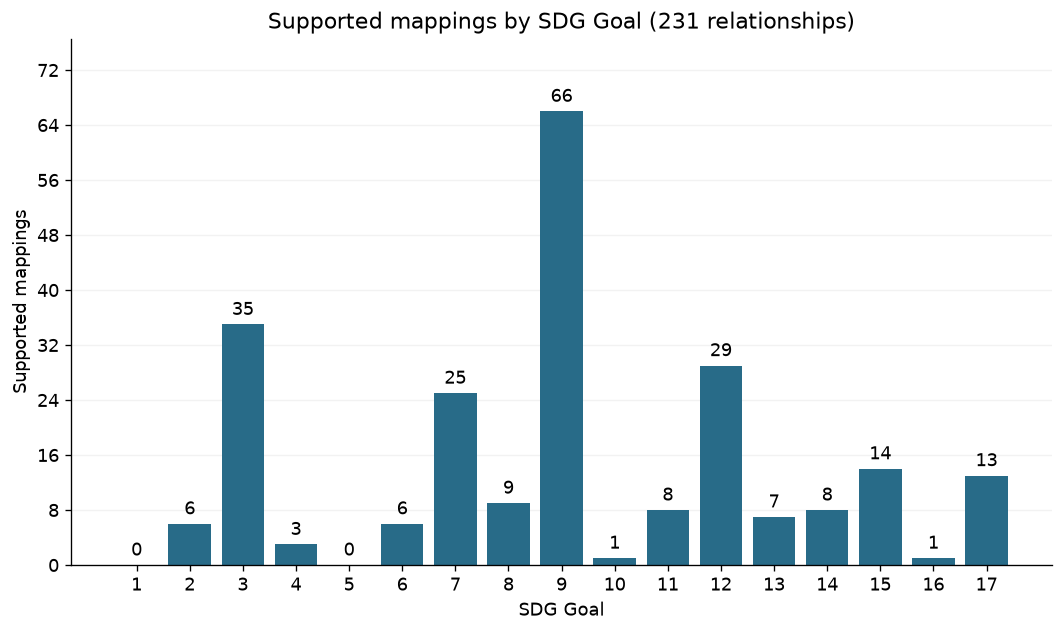

In [11]:
goal_counts=mapping.groupby('sdg_goal').size().reindex(range(1,18),fill_value=0)
chart(goal_counts,'Supported mappings by SDG Goal (231 relationships)','SDG Goal','Supported mappings','mappings_by_sdg_goal.png')

Goal 9 is the largest group in this selected corpus. Counts may reflect selection, retrieval and model tendencies; they do not show causal impact or CORDIS-wide prevalence.

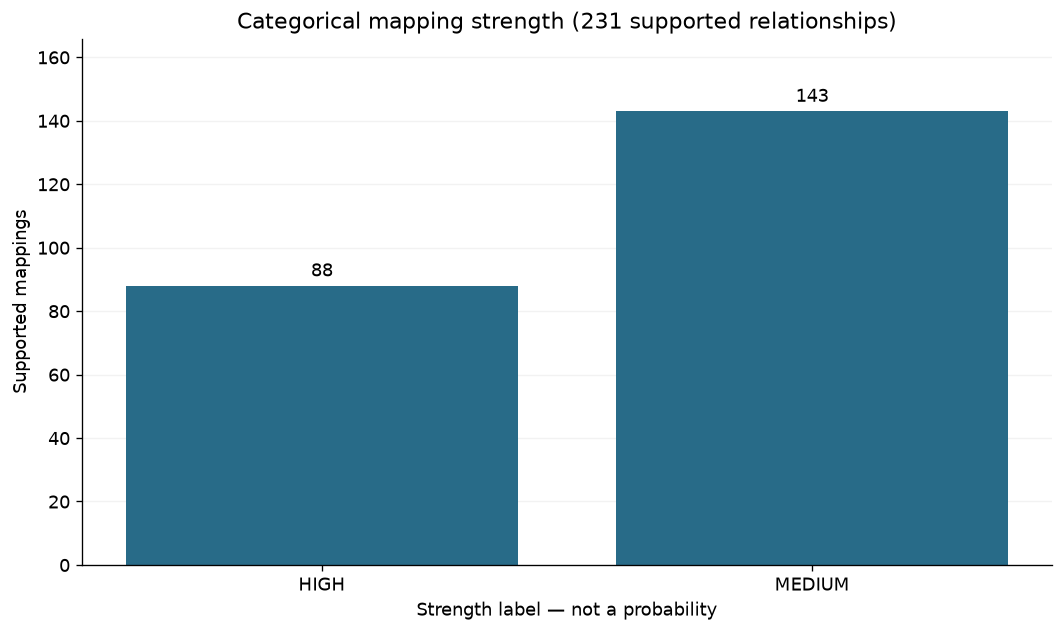

In [12]:
confidence=mapping['confidence_level'].value_counts().reindex(['HIGH','MEDIUM'],fill_value=0)
chart(confidence,'Categorical mapping strength (231 supported relationships)','Strength label — not a probability','Supported mappings','confidence_distribution.png')

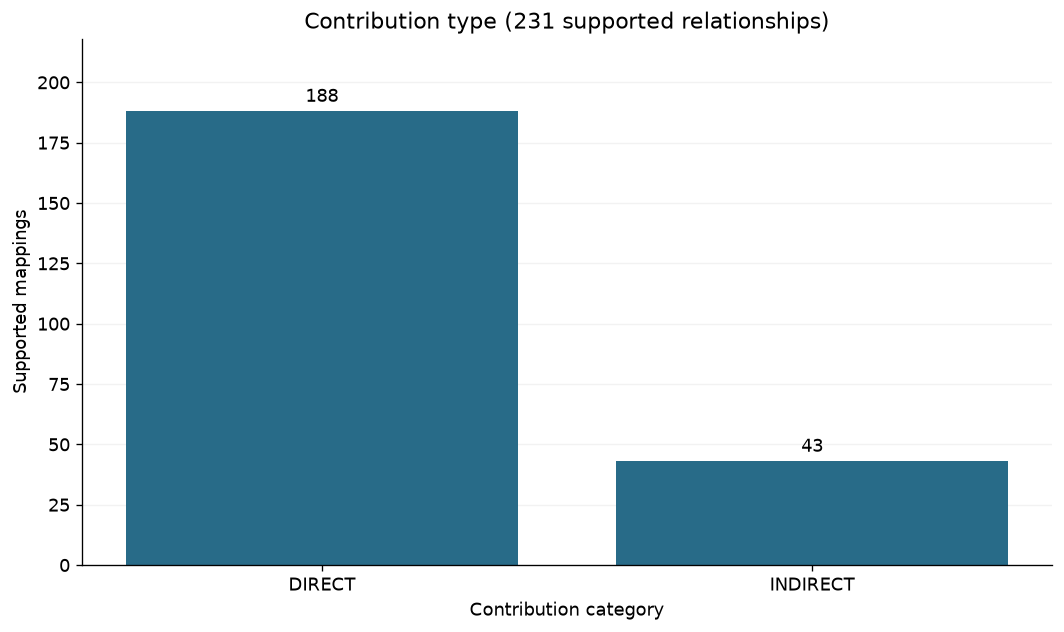

In [13]:
contribution=mapping['contribution_type'].value_counts().reindex(['DIRECT','INDIRECT'],fill_value=0)
chart(contribution,'Contribution type (231 supported relationships)','Contribution category','Supported mappings','contribution_distribution.png')

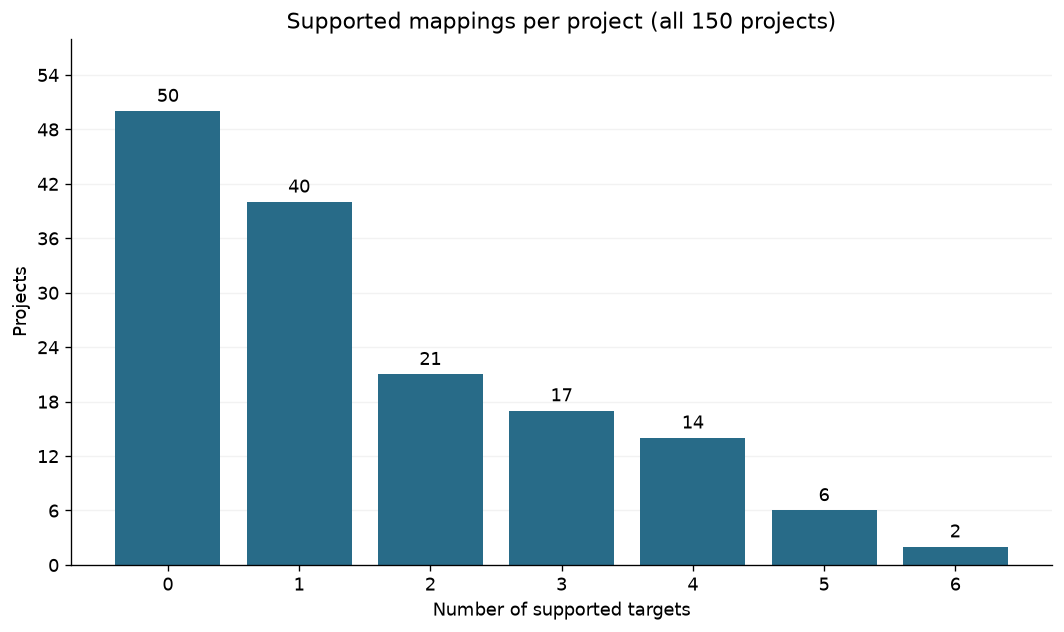

In [14]:
per_project=projects['n_supported_mappings'].value_counts().sort_index()
chart(per_project,'Supported mappings per project (all 150 projects)','Number of supported targets','Projects','mappings_per_project.png')

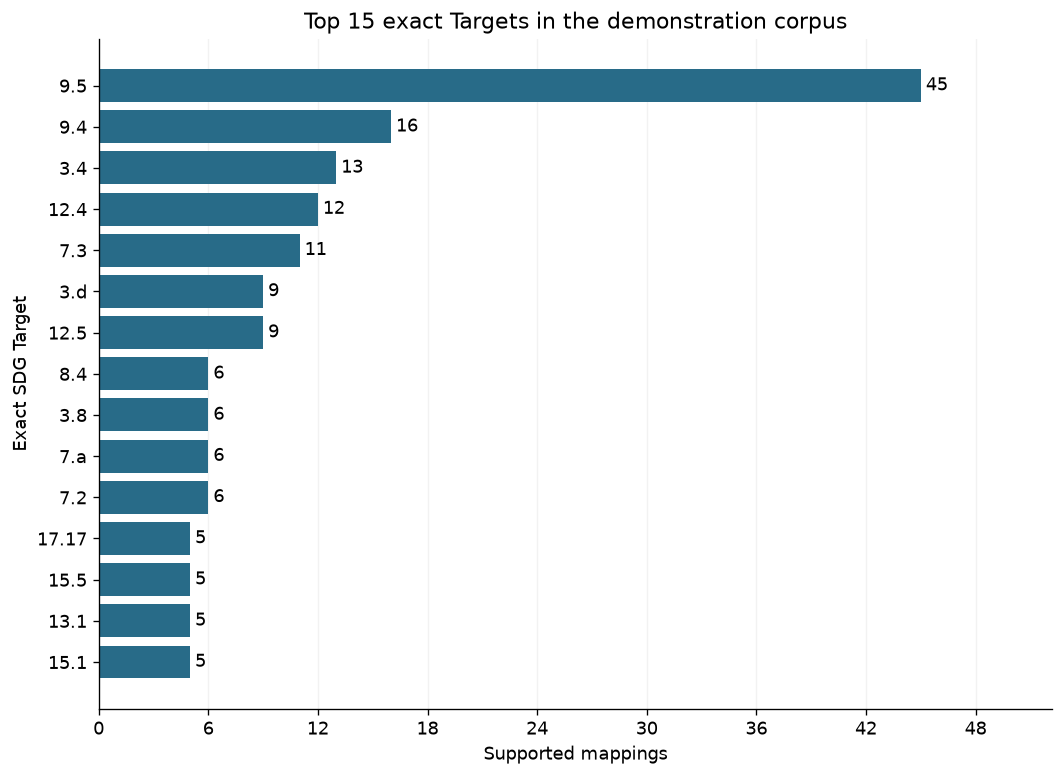

787

In [15]:
order=[code for code,count in quality['top_15_targets']]
top15=mapping['target_code'].value_counts().reindex(order)
if top15.tolist()!=[count for code,count in quality['top_15_targets']]:
    raise ValueError('Top target counts differ')
chart(top15,'Top 15 exact Targets in the demonstration corpus','Supported mappings','Exact SDG Target','top_15_targets.png',horizontal=True)
(FIGURES/'figure_values.json').write_text(json.dumps(chart_values,indent=2),encoding='utf-8')

Target 9.5 has 45 of 231 supported mappings (19.48%). This is an important concentration to examine, not validation of generic research-to-SDG-9.5 mapping.

## L. Uncertainty and evidence

No project is forced to have a mapping. Four system-invalid cases are preserved separately without semantic repair. HIGH/MEDIUM are categorical labels, not probabilities; public mappings are model-supported, not human-certified ground truth. Segment IDs point to the same project and source field. Public evidence text collapses whitespace; retained source segments preserve the original text.

In [16]:
display(uncertain[['project_id','target_code','status','system_error']])
display(mapping[['project_id','target_code','confidence_level','source_fields','evidence_segment_ids']].head())

,project_id,target_code,status,system_error
0,101087257,17.8,SYSTEM_UNCERTAIN,invalid_scope_gate
1,101181294,15.5,SYSTEM_UNCERTAIN,invalid_required_depth_grader
2,101211177,9.5,SYSTEM_UNCERTAIN,invalid_required_depth_grader
3,101279745,3.8,SYSTEM_UNCERTAIN,invalid_required_depth_grader


,project_id,target_code,confidence_level,source_fields,evidence_segment_ids
0,101039986,7.3,MEDIUM,objective,objective_05; objective_09; objective_10; obje...
1,101041677,3.4,MEDIUM,objective,objective_02; objective_05; objective_06; obje...
2,101041677,9.5,HIGH,objective,objective_03; objective_05; objective_06
3,101056784,7.3,MEDIUM,objective,objective_01; objective_03; objective_04; obje...
4,101056883,12.4,MEDIUM,objective,objective_02; objective_04; objective_06; obje...


## M. Limitations

- Retrieval tests only the top 10 of 169 Targets per project. Relevant targets outside that set cannot be recovered by the verifier.
- Production is Target-only. The retained EU vocabulary also contains Goals, Indicators and Series, but no production Indicator/Series evaluation was performed. Blank `narrower_concept` fields mean outside production scope, not individually rejected concepts.
- V8 FAILED the complete internal development gate. Repeated development-set reuse and the change from GPT-5.4 Mini to GPT-6 Luna prevent interpreting those metrics as independent final-deployment accuracy.
- No independent final-Luna human gold set establishes final precision/recall. Strong/weak separation is unstable in the development results; HIGH/MEDIUM are categorical strength labels, not probabilities.
- The unchanged scope prompt says `ONE Horizon Europe project`. The frozen corpus has 108 HORIZON_EUROPE and 42 OTHER projects: 420 scope evaluations used inaccurate framework wording; 28 supported mappings belong to OTHER. Verification is based on target/evidence, but the prompt was not framework-neutral. Results were preserved, not relabelled or rerun.
- The 150-project deterministic, privacy-screened demonstration is not a probability sample and cannot estimate CORDIS-wide SDG prevalence. OTHER is the retained framework category; it is not proof of Horizon 2020 integration.
- The original upstream CORDIS retrieval/download date could not be recovered reliably. Do not infer it from later file modification times.
- Final selection/retrieval/production orchestration scripts were not recovered in the repository search. Manifests document their settings; this release reproduces frozen-output lineage, deterministic composition and descriptive analysis, not a fresh end-to-end data acquisition/model run.
- The provider model ID is recorded, but an immutable provider backend snapshot is not available. Future API outputs are not guaranteed identical. No API calls occur in this release app, tests or notebook.
- Four system-invalid results remain separate. An unmapped project means no supported result among evaluated candidates, not proof that the project contributes to no SDG.
- Target 9.5 accounts for 45/231 supported mappings (19.48%). This is a concentration diagnostic, not evidence of correctness or an estimate of research-sector prevalence.
- Automated privacy screening is heuristic. No contact fields or credentials are included; historical names and proper nouns may remain in project text. Original-license/third-party reuse review and public deployment remain pending.


## N. Execution and integrity

Every cell has a stable nbformat ID. The test below checks release-local hashes, all deterministic compositions, evidence ownership, table counts, Excel consistency and packaging hygiene. It does not call a model. A passing software integrity test does not establish scientific validity. This notebook can be rerun from either the release root or notebooks directory.

In [17]:
import subprocess, sys
completed = subprocess.run([sys.executable,'-B',str(ROOT/'tests/release_integrity_test.py'),'--no-manifest'],cwd=ROOT,capture_output=True,text=True)
if completed.returncode:
    raise RuntimeError(completed.stdout + completed.stderr)
report=json.loads(completed.stdout)
display(pd.Series({'Checks passed':report['passed'],'Checks failed':report['failed'],'Inference calls':0,'Reserve semantic access':False}).to_frame('Release-local checks'))

,Release-local checks
Checks passed,62
Checks failed,0
Inference calls,0
Reserve semantic access,False
